<a href="https://colab.research.google.com/github/GrandMoze/DeepfakeDetection-MobileNetV2-CampusProject/blob/main/Copy_of_IF640_AI_for_Cyber_Kelompok_Moze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sanikatiwarekar_deep_fake_detection_dfd_entire_original_dataset_path = kagglehub.dataset_download('sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'deep-fake-detection-dfd-entire-original-dataset' dataset.
Data source import complete.


In [2]:
import os

print("=== Struktur Direktori di /kaggle/input ===")
# Berjalan menyusuri semua folder di dalam input Kaggle
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(f"Direktori ditemukan: {dirname}")

    # Hanya print 2 file pertama dari setiap folder agar output tidak kepanjangan
    for filename in filenames[:2]:
        print(os.path.join(dirname, filename))
    print("-" * 40)

=== Struktur Direktori di /kaggle/input ===
Direktori ditemukan: /kaggle/input
----------------------------------------
Direktori ditemukan: /kaggle/input/deep-fake-detection-dfd-entire-original-dataset
----------------------------------------
Direktori ditemukan: /kaggle/input/deep-fake-detection-dfd-entire-original-dataset/DFD_original sequences
/kaggle/input/deep-fake-detection-dfd-entire-original-dataset/DFD_original sequences/26__walking_down_street_outside_angry.mp4
/kaggle/input/deep-fake-detection-dfd-entire-original-dataset/DFD_original sequences/08__talking_against_wall.mp4
----------------------------------------
Direktori ditemukan: /kaggle/input/deep-fake-detection-dfd-entire-original-dataset/DFD_manipulated_sequences
----------------------------------------
Direktori ditemukan: /kaggle/input/deep-fake-detection-dfd-entire-original-dataset/DFD_manipulated_sequences/DFD_manipulated_sequences
/kaggle/input/deep-fake-detection-dfd-entire-original-dataset/DFD_manipulated_seque

Total Video Asli (Real): 363
Total Video Manipulasi (Fake): 3068


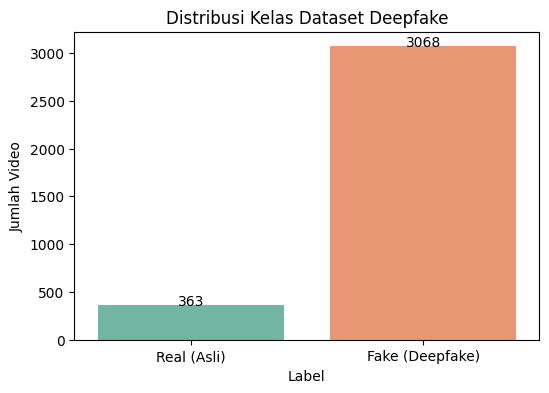


=== 2. ANALISIS KARAKTERISTIK VIDEO (SAMPEL DATA) ===

Sampel Karakteristik Video:


,Filename,Label,Resolution,FPS,Total Frames,Duration (Sec)
0,26__walking_down_street_outside_angry.mp4,Real,1920x1080,24.0,625,26.04
1,08__talking_against_wall.mp4,Real,1920x1080,24.0,1100,45.83
2,14__walking_down_indoor_hall_disgust.mp4,Real,1920x1080,24.0,1465,61.04
3,08__walking_down_street_outside_angry.mp4,Real,1920x1080,24.0,694,28.92
4,05__outside_talking_still_laughing.mp4,Real,1920x1080,24.0,960,40.00


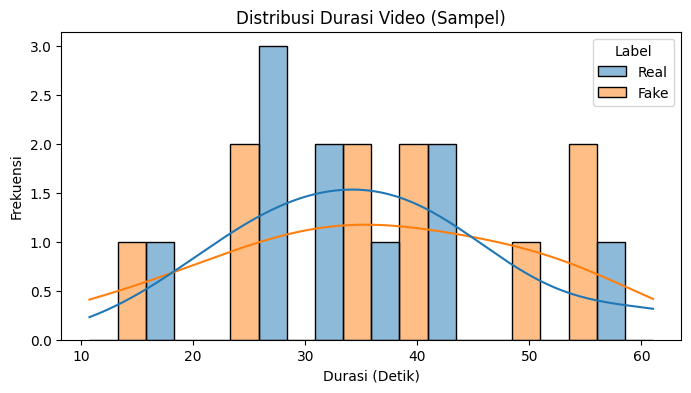


=== 3. ANALISIS PERUBAHAN INTENSITAS PIKSEL (TEMPORAL ANALYSIS) ===


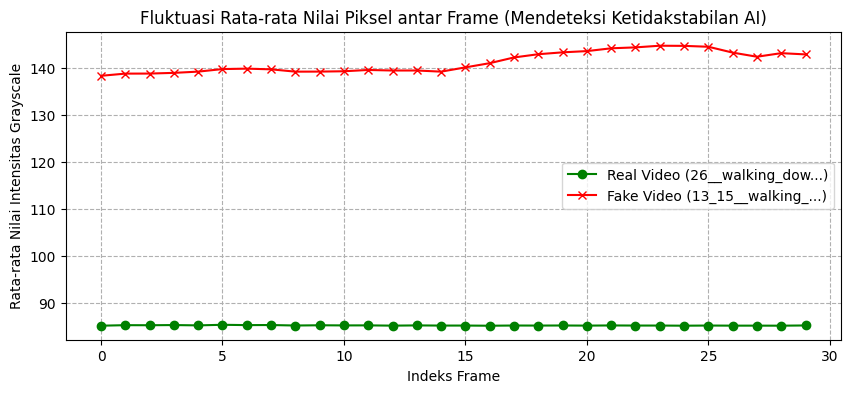

In [3]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Update DATASET_PATH to the actual downloaded path
DATASET_PATH = sanikatiwarekar_deep_fake_detection_dfd_entire_original_dataset_path

REAL_VIDEO_DIR = os.path.join(DATASET_PATH, 'DFD_original sequences')
FAKE_VIDEO_DIR = os.path.join(DATASET_PATH, 'DFD_manipulated_sequences', 'DFD_manipulated_sequences')

#analisis distribusi target
list_real = [f for f in os.listdir(REAL_VIDEO_DIR) if f.endswith(('.mp4', '.avi', '.mkv'))]
list_fake = [f for f in os.listdir(FAKE_VIDEO_DIR) if f.endswith(('.mp4', '.avi', '.mkv'))]

df_dist = pd.DataFrame({
    'Label': ['Real (Asli)', 'Fake (Deepfake)'],
    'Jumlah Video': [len(list_real), len(list_fake)]
})

print(f"Total Video Asli (Real): {len(list_real)}")
print(f"Total Video Manipulasi (Fake): {len(list_fake)}")

# Visualisasi Distribusi Kelas
plt.figure(figsize=(6, 4))
sns.barplot(x='Label', y='Jumlah Video', data=df_dist, hue='Label', palette='Set2', legend=False)
plt.title('Distribusi Kelas Dataset Deepfake')
plt.ylabel('Jumlah Video')
for index, row in df_dist.iterrows():
    plt.text(index, row['Jumlah Video'] + 1, str(row['Jumlah Video']), color='black', ha="center")
plt.show()

# =====================================================================
# EDA 2: ANALISIS PROPERTI VIDEO (RESOLUSI, FPS, DURASI)
# =====================================================================
print("\n=== 2. ANALISIS KARAKTERISTIK VIDEO (SAMPEL DATA) ===")

def analyze_video_properties(video_dir, label, sample_size=10):
    video_files = [f for f in os.listdir(video_dir) if f.endswith(('.mp4', '.avi', '.mkv'))][:sample_size]
    data = []

    for vid in video_files:
        path = os.path.join(video_dir, vid)
        cap = cv2.VideoCapture(path)

        if cap.isOpened():
            fps = cap.get(cv2.CAP_PROP_FPS)
            total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
            width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
            height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
            duration = total_frames / fps if fps > 0 else 0

            data.append({
                'Filename': vid,
                'Label': label,
                'Resolution': f"{int(width)}x{int(height)}",
                'FPS': round(fps, 2),
                'Total Frames': int(total_frames),
                'Duration (Sec)': round(duration, 2)
            })
        cap.release()
    return pd.DataFrame(data)

# Mengambil sampel 10 video dari masing-masing kelas untuk melihat karakteristiknya
df_real_props = analyze_video_properties(REAL_VIDEO_DIR, 'Real', sample_size=10)
df_fake_props = analyze_video_properties(FAKE_VIDEO_DIR, 'Fake', sample_size=10)
df_all_props = pd.concat([df_real_props, df_fake_props], ignore_index=True)

# Tampilkan tabel sampel properti video
print("\nSampel Karakteristik Video:")
display(df_all_props.head(5))

# Visualisasi Distribusi Durasi Video Sampel
plt.figure(figsize=(8, 4))
sns.histplot(data=df_all_props, x='Duration (Sec)', hue='Label', kde=True, multiple='dodge', bins=10)
plt.title('Distribusi Durasi Video (Sampel)')
plt.xlabel('Durasi (Detik)')
plt.ylabel('Frekuensi')
plt.show()

# =====================================================================
# EDA 3: VISUALISASI PERBANDINGAN PERUBAHAN FRAME (TEMPORAL FLICKER)
# =====================================================================
print("\n=== 3. ANALISIS PERUBAHAN INTENSITAS PIKSEL (TEMPORAL ANALYSIS) ===")

def get_pixel_variance(video_path):
    cap = cv2.VideoCapture(video_path)
    frame_means = []

    # Ambil 30 frame pertama untuk melihat fluktuasi cahaya/piksel
    for _ in range(30):
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_means.append(np.mean(gray))

    cap.release()
    return frame_means

# Ambil 1 contoh video dari masing-masing kelas
if len(list_real) > 0 and len(list_fake) > 0:
    sample_real_path = os.path.join(REAL_VIDEO_DIR, list_real[0])
    sample_fake_path = os.path.join(FAKE_VIDEO_DIR, list_fake[0])

    real_variance = get_pixel_variance(sample_real_path)
    fake_variance = get_pixel_variance(sample_fake_path)

    plt.figure(figsize=(10, 4))
    plt.plot(real_variance, label=f'Real Video ({list_real[0][:15]}...)', color='green', marker='o')
    plt.plot(fake_variance, label=f'Fake Video ({list_fake[0][:15]}...)', color='red', marker='x')
    plt.title('Fluktuasi Rata-rata Nilai Piksel antar Frame (Mendeteksi Ketidakstabilan AI)')
    plt.xlabel('Indeks Frame')
    plt.ylabel('Rata-rata Nilai Intensitas Grayscale')
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.show()

In [4]:
from pathlib import Path

In [5]:
# ===== PATH CONFIGURATION =====
DATASET_PATH = '/kaggle/input/deep-fake-detection-dfd-entire-original-dataset'

REAL_VIDEO_DIR = '/kaggle/input/deep-fake-detection-dfd-entire-original-dataset/DFD_original sequences'
FAKE_VIDEO_DIR = '/kaggle/input/deep-fake-detection-dfd-entire-original-dataset/DFD_manipulated_sequences/DFD_manipulated_sequences'

# Define Path objects for directories
REAL_DIR = Path(REAL_VIDEO_DIR)
FAKE_DIR = Path(FAKE_VIDEO_DIR)

# Output directories
OUTPUT_DIR = Path('/kaggle/working')
FRAME_DIR  = OUTPUT_DIR / 'frames'
FACE_DIR   = OUTPUT_DIR / 'faces'
MODEL_DIR  = OUTPUT_DIR / 'models'

for d in [FRAME_DIR, FACE_DIR, MODEL_DIR,
          FACE_DIR/'real', FACE_DIR/'fake']:
    d.mkdir(parents=True, exist_ok=True)

# ===== HYPERPARAMETER =====
CFG = {
    # Frame extraction
    'frames_per_video'   : 20,     # jumlah frame per video
    'frame_strategy'     : 'uniform',  # 'uniform' | 'random'

    # Face detection
    'face_size'          : 224,    # output face crop size
    'face_margin'        : 0.3,    # margin sekitar face bbox
    'mtcnn_thresholds'   : [0.6, 0.7, 0.7],

    # Training
    'img_size'           : 224,
    'batch_size'         : 32,
    'num_epochs'         : 25,
    'lr'                 : 1e-4,
    'weight_decay'       : 1e-4,
    'lr_scheduler'       : 'cosine',  # 'cosine' | 'step'
    'warmup_epochs'      : 3,
    'dropout_rate'       : 0.5,
    'label_smoothing'    : 0.1,

    # Data split
    'val_size'           : 0.15,
    'test_size'          : 0.15,

    # Misc
    'num_workers'        : 2,
    'pin_memory'         : True,
    'early_stopping_patience': 7,
    'freeze_epochs'      : 5,   # epochs MobileNetV2 backbone difreeze
}

# GAN manipulation types yang ditarget
GAN_METHODS = [
    'Deepfakes',       # AutoEncoder-based face swap
    'Face2Face',       # Expression transfer
    'FaceSwap',        # 3D face swap
    'NeuralTextures',  # Neural texture rendering
    'FaceShifter',     # High-fidelity face swapping
]

print('Konfigurasi berhasil dimuat!')
print(f'Target GAN methods: {GAN_METHODS}')

Konfigurasi berhasil dimuat!
Target GAN methods: ['Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures', 'FaceShifter']


In [11]:
import torch

# Define the device for PyTorch operations
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


In [6]:
from collections import defaultdict

In [7]:
def get_video_files(directory: Path, extensions=('.mp4', '.avi', '.mov')):
    """Rekursif mencari semua file video."""
    videos = []
    for ext in extensions:
        videos.extend(list(directory.rglob(f'*{ext}')))
    return sorted(videos)


def extract_frames_from_video(video_path: Path,
                               n_frames: int = 20,
                               strategy: str = 'uniform') -> list:
    """
    Ekstrak frame dari video.
    strategy: 'uniform' = distribusi merata, 'random' = random sampling
    Returns: list of numpy arrays (BGR)
    """
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return []

    n_frames = min(n_frames, total_frames)

    if strategy == 'uniform':
        indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)
    else:  # random
        # Skip awal & akhir 5% untuk hindari fade in/out
        start = int(total_frames * 0.05)
        end   = int(total_frames * 0.95)
        indices = sorted(random.sample(range(start, end), n_frames))

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)

    cap.release()
    return frames


def detect_gan_method(video_path: Path) -> str:
    """Deteksi GAN method dari path video."""
    path_str = str(video_path).lower()
    for method in GAN_METHODS:
        if method.lower() in path_str:
            return method
    return 'Unknown'


# Collect all video paths
real_videos = get_video_files(REAL_DIR) if REAL_DIR.exists() else []
fake_videos = get_video_files(FAKE_DIR) if FAKE_DIR.exists() else []

print(f'Real videos ditemukan : {len(real_videos)}')
print(f'Fake videos ditemukan : {len(fake_videos)}')
print(f'Total               : {len(real_videos) + len(fake_videos)}')

# Analisis distribusi GAN methods
gan_counts = defaultdict(int)
for v in fake_videos:
    gan_counts[detect_gan_method(v)] += 1

print('\nDistribusi GAN Methods:')
for method, count in sorted(gan_counts.items(), key=lambda x: -x[1]):
    print(f'  {method:20s}: {count} videos')

Real videos ditemukan : 363
Fake videos ditemukan : 3068
Total               : 3431

Distribusi GAN Methods:
  Unknown             : 3068 videos


In [8]:
from tqdm.notebook import tqdm

def extract_all_frames(video_list: list,
                        label: int,
                        output_dir: Path,
                        cfg: dict) -> pd.DataFrame:
    """
    Ekstrak frame dari semua video dan simpan ke disk.
    Returns: DataFrame metadata
    """
    records = []
    label_name = 'real' if label == 0 else 'fake'
    save_dir = output_dir / label_name
    save_dir.mkdir(parents=True, exist_ok=True)

    for video_path in tqdm(video_list, desc=f'Extracting {label_name} frames'):
        video_name = video_path.stem
        gan_method = detect_gan_method(video_path) if label == 1 else 'Real'

        frames = extract_frames_from_video(
            video_path,
            n_frames=cfg['frames_per_video'],
            strategy=cfg['frame_strategy']
        )

        for i, frame in enumerate(frames):
            frame_filename = f'{video_name}_f{i:03d}.jpg'
            frame_path = save_dir / frame_filename
            cv2.imwrite(str(frame_path), frame)

            records.append({
                'frame_path' : str(frame_path),
                'video_name' : video_name,
                'video_path' : str(video_path),
                'frame_idx'  : i,
                'label'      : label,
                'label_name' : label_name,
                'gan_method' : gan_method,
            })

    return pd.DataFrame(records)


# Jalankan ekstraksi
print('Memulai ekstraksi frame...')
df_real = extract_all_frames(real_videos[:100], label=0, output_dir=FRAME_DIR, cfg=CFG)
df_fake = extract_all_frames(fake_videos[:100], label=1, output_dir=FRAME_DIR, cfg=CFG)

df_all = pd.concat([df_real, df_fake], ignore_index=True)
df_all.to_csv(OUTPUT_DIR / 'frame_metadata.csv', index=False)

print(f'\nTotal frames  : {len(df_all)}')
print(f'Real frames   : {len(df_real)}')
print(f'Fake frames   : {len(df_fake)}')
print(f'Imbalance ratio: 1:{len(df_fake)//max(len(df_real),1)}')


Memulai ekstraksi frame...


Extracting real frames:   0%|          | 0/100 [00:00<?, ?it/s]

Extracting fake frames:   0%|          | 0/100 [00:00<?, ?it/s]


Total frames  : 3985
Real frames   : 2000
Fake frames   : 1985
Imbalance ratio: 1:0


In [9]:
!pip install facenet_pytorch

In [12]:
from facenet_pytorch import MTCNN

# Inisialisasi MTCNN
mtcnn = MTCNN(
    image_size=CFG['face_size'],
    margin=int(CFG['face_size'] * CFG['face_margin']),
    min_face_size=40,
    thresholds=CFG['mtcnn_thresholds'],
    factor=0.709,
    post_process=False,
    keep_all=False,  # hanya ambil wajah terbesar
    device=DEVICE
)


def crop_face_from_frame(frame_bgr: np.ndarray,
                          face_size: int = 224) -> np.ndarray | None:
    """
    Deteksi dan crop wajah dari frame.
    Returns: numpy array (RGB) atau None jika tidak ada wajah.
    """
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    from PIL import Image
    img_pil = Image.fromarray(frame_rgb)

    try:
        face_tensor = mtcnn(img_pil)
        if face_tensor is None:
            return None
        # Convert tensor ke numpy
        face_np = face_tensor.permute(1, 2, 0).numpy().astype(np.uint8)
        face_resized = cv2.resize(face_np, (face_size, face_size))
        return face_resized
    except Exception:
        return None


def process_faces_batch(df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    """Proses deteksi wajah untuk semua frame."""
    face_records = []
    failed = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Detecting faces'):
        frame = cv2.imread(row['frame_path'])
        if frame is None:
            failed += 1
            continue

        face = crop_face_from_frame(frame, cfg['face_size'])

        if face is not None:
            label_dir = FACE_DIR / row['label_name']
            face_filename = Path(row['frame_path']).stem + '_face.jpg'
            face_path = label_dir / face_filename

            # Simpan dalam format RGB
            face_bgr = cv2.cvtColor(face, cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(face_path), face_bgr)

            rec = row.to_dict()
            rec['face_path'] = str(face_path)
            face_records.append(rec)
        else:
            failed += 1

    print(f'Face detection selesai. Berhasil: {len(face_records)}, Gagal: {failed}')
    return pd.DataFrame(face_records)


# Jalankan face detection
df_faces = process_faces_batch(df_all, CFG)
df_faces.to_csv(OUTPUT_DIR / 'face_metadata.csv', index=False)

print(f'\nTotal face crops  : {len(df_faces)}')
print(df_faces['label_name'].value_counts())

Detecting faces:   0%|          | 0/3985 [00:00<?, ?it/s]

Face detection selesai. Berhasil: 3940, Gagal: 45

Total face crops  : 3940
label_name
fake    1979
real    1961
Name: count, dtype: int64


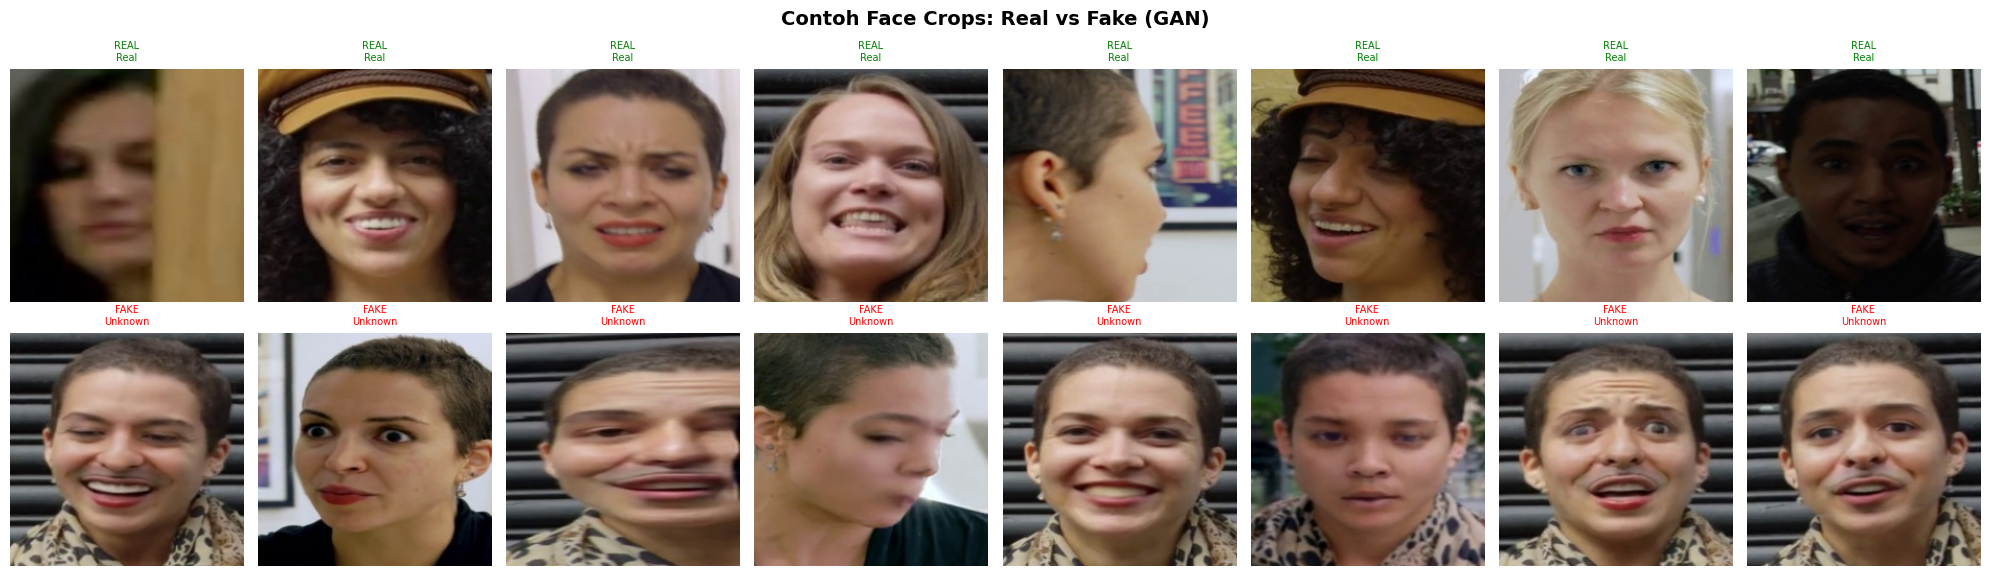

In [13]:
# Visualisasi contoh face crops
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Contoh Face Crops: Real vs Fake (GAN)', fontsize=14, fontweight='bold')

for label_idx, label_name in enumerate(['real', 'fake']):
    samples = df_faces[df_faces['label_name'] == label_name].sample(
        min(8, len(df_faces[df_faces['label_name'] == label_name]))
    )
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        ax = axes[label_idx][col_idx]
        img = cv2.imread(row['face_path'])
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
        ax.set_title(f"{label_name.upper()}\n{row.get('gan_method', '')}",
                     fontsize=7,
                     color='green' if label_name == 'real' else 'red')
        ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'face_crops_sample.png', dpi=150)
plt.show()

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import cv2
import pandas as pd

# Define a random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Define the device
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Load metadata
df_faces = pd.read_csv(OUTPUT_DIR / 'face_metadata.csv')

# ===== AUGMENTASI KHUSUS GAN ARTIFACT DETECTION =====
# Tambah augmentasi yang membantu mendeteksi artefak GAN:
# - JPEG compression artifacts
# - Color jittering (GAN sering produce warna tidak natural)
# - Frequency domain perturbation (via noise)

train_transform = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.GaussNoise(p=0.3),
    A.ImageCompression(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
    A.CoarseDropout(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(CFG['img_size'], CFG['img_size']),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])


class DeepfakeDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['face_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']

        label = torch.tensor(row['label'], dtype=torch.long)
        return img, label


# ===== TRAIN/VAL/TEST SPLIT (video-level agar tidak leak) =====
unique_videos = df_faces['video_name'].unique()
labels_per_video = df_faces.groupby('video_name')['label'].first()

train_vids, temp_vids = train_test_split(
    unique_videos, test_size=CFG['val_size'] + CFG['test_size'],
    stratify=labels_per_video[unique_videos], random_state=SEED
)
val_vids, test_vids = train_test_split(
    temp_vids, test_size=CFG['test_size'] / (CFG['val_size'] + CFG['test_size']),
    stratify=labels_per_video[temp_vids], random_state=SEED
)

df_train = df_faces[df_faces['video_name'].isin(train_vids)]
df_val   = df_faces[df_faces['video_name'].isin(val_vids)]
df_test  = df_faces[df_faces['video_name'].isin(test_vids)]

print(f'Train: {len(df_train)} frames ({df_train["label"].mean():.2%} fake)')
print(f'Val  : {len(df_val)}   frames ({df_val["label"].mean():.2%} fake)')
print(f'Test : {len(df_test)}  frames ({df_test["label"].mean():.2%} fake)')

Train: 2758 frames (50.11% fake)
Val  : 592   frames (50.51% fake)
Test : 590  frames (50.51% fake)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
from torch.utils.data import WeightedRandomSampler, DataLoader
import torch.nn as nn
import torchvision.models as models

# ===== WEIGHTED SAMPLER untuk handle class imbalance =====
class_counts = df_train['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = df_train['label'].map(dict(enumerate(class_weights))).values
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_dataset = DeepfakeDataset(df_train, transform=train_transform)
val_dataset   = DeepfakeDataset(df_val,   transform=val_transform)
test_dataset  = DeepfakeDataset(df_test,  transform=val_transform)

train_loader = DataLoader(
    train_dataset, batch_size=CFG['batch_size'],
    sampler=sampler, num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)
val_loader = DataLoader(
    val_dataset, batch_size=CFG['batch_size'],
    shuffle=False, num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)
test_loader = DataLoader(
    test_dataset, batch_size=CFG['batch_size'],
    shuffle=False, num_workers=CFG['num_workers'],
    pin_memory=CFG['pin_memory']
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

class MobileNetV2DeepfakeDetector(nn.Module):
    """
    MobileNetV2 fine-tuned untuk deteksi deepfake GAN.

    Modifikasi khusus GAN detection:
    - Attention mechanism pada high-level features
    - Multi-scale feature fusion
    - Dropout regularisasi tinggi
    """
    def __init__(self, num_classes: int = 2, dropout: float = 0.5,
                 freeze_backbone: bool = True):
        super().__init__()

        # ---- Backbone: MobileNetV2 pretrained ----
        backbone = models.mobilenet_v2(pretrained=True)
        self.features = backbone.features  # output: [B, 1280, 7, 7]

        if freeze_backbone:
            for param in self.features.parameters():
                param.requires_grad = False
            # Unfreeze layer terakhir saja
            for param in self.features[-3:].parameters():
                param.requires_grad = True

        # ---- Channel Attention (Squeeze-and-Excitation) ----
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Linear(128, 1280),
            nn.Sigmoid(),
        )

        # ---- Classifier Head ----
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1280, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # Feature extraction
        feat = self.features(x)  # [B, 1280, 7, 7]

        # Channel attention
        attn = self.channel_attention(feat)  # [B, 1280]
        attn = attn.unsqueeze(-1).unsqueeze(-1)  # [B, 1280, 1, 1]
        feat = feat * attn  # gated features

        # Classification
        out = self.classifier(feat)
        return out

    def unfreeze_backbone(self, n_layers: int = -1):
        """Unfreeze n_layers terakhir backbone untuk fine-tuning."""
        if n_layers == -1:
            for param in self.features.parameters():
                param.requires_grad = True
        else:
            layers = list(self.features.children())
            for layer in layers[-n_layers:]:
                for param in layer.parameters():
                    param.requires_grad = True


model = MobileNetV2DeepfakeDetector(
    num_classes=2,
    dropout=CFG['dropout_rate'],
    freeze_backbone=True
).to(DEVICE)

# Hitung parameter
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameter    : {total_params:,}')
print(f'Trainable parameter: {trainable_params:,} ({trainable_params/total_params:.1%})')

Train batches: 87
Val batches  : 19
Test batches : 19


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 92.3MB/s]

Total parameter    : 3,276,034
Trainable parameter: 2,258,242 (68.9%)


In [ ]:
class MobileNetV2DeepfakeDetector(nn.Module):
    """
    MobileNetV2 fine-tuned untuk deteksi deepfake GAN.

    Modifikasi khusus GAN detection:
    - Attention mechanism pada high-level features
    - Multi-scale feature fusion
    - Dropout regularisasi tinggi
    """
    def __init__(self, num_classes: int = 2, dropout: float = 0.5,
                 freeze_backbone: bool = True):
        super().__init__()

        # ---- Backbone: MobileNetV2 pretrained ----
        backbone = models.mobilenet_v2(pretrained=True)
        self.features = backbone.features  # output: [B, 1280, 7, 7]

        if freeze_backbone:
            for param in self.features.parameters():
                param.requires_grad = False
            # Unfreeze layer terakhir saja
            for param in self.features[-3:].parameters():
                param.requires_grad = True

        # ---- Channel Attention (Squeeze-and-Excitation) ----
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Linear(128, 1280),
            nn.Sigmoid(),
        )

        # ---- Classifier Head ----
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1280, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # Feature extraction
        feat = self.features(x)  # [B, 1280, 7, 7]

        # Channel attention
        attn = self.channel_attention(feat)  # [B, 1280]
        attn = attn.unsqueeze(-1).unsqueeze(-1)  # [B, 1280, 1, 1]
        feat = feat * attn  # gated features

        # Classification
        out = self.classifier(feat)
        return out

    def unfreeze_backbone(self, n_layers: int = -1):
        """Unfreeze n_layers terakhir backbone untuk fine-tuning."""
        if n_layers == -1:
            for param in self.features.parameters():
                param.requires_grad = True
        else:
            layers = list(self.features.children())
            for layer in layers[-n_layers:]:
                for param in layer.parameters():
                    param.requires_grad = True


model = MobileNetV2DeepfakeDetector(
    num_classes=2,
    dropout=CFG['dropout_rate'],
    freeze_backbone=True
).to(DEVICE)

# Hitung parameter
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameter    : {total_params:,}')
print(f'Trainable parameter: {trainable_params:,} ({trainable_params/total_params:.1%})')

Total parameter    : 3,276,034
Trainable parameter: 2,258,242 (68.9%)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
import numpy as np

# ===== LOSS: Label Smoothing CrossEntropy =====
criterion = nn.CrossEntropyLoss(
    label_smoothing=CFG['label_smoothing'],
    weight=torch.tensor([1.0, class_counts[0]/class_counts[1]], device=DEVICE)
)

# ===== OPTIMIZER =====
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay']
)

# ===== SCHEDULER: Cosine Annealing with Warmup =====
def warmup_cosine_lr(epoch):
    if epoch < CFG['warmup_epochs']:
        return (epoch + 1) / CFG['warmup_epochs']
    progress = (epoch - CFG['warmup_epochs']) / (CFG['num_epochs'] - CFG['warmup_epochs'])
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine_lr)


# ===== TRAINING UTILITIES =====
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in tqdm(loader, leave=False, desc='Training'):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        probs = F.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        total_loss += loss.item() * imgs.size(0)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    auc = roc_auc_score(all_labels, all_probs)
    return avg_loss, accuracy, auc, np.array(all_probs), np.array(all_labels)

In [ ]:
# ===== MAIN TRAINING LOOP =====
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': [],
    'val_auc': [],    'lr': []
}

early_stopping = EarlyStopping(patience=CFG['early_stopping_patience'])
best_val_auc = 0.0
best_model_path = MODEL_DIR / 'best_mobilenetv2_deepfake.pth'

# Re-define criterion with correct dtype for weight tensor
# This is a workaround because the original criterion definition in eterP6JUUu9e
# produced a weight tensor of type Double, causing a RuntimeError.
criterion = nn.CrossEntropyLoss(
    label_smoothing=CFG['label_smoothing'],
    weight=torch.tensor([1.0, class_counts[0]/class_counts[1]], device=DEVICE, dtype=torch.float)
)


print('='*60)
print('MULAI TRAINING')
print('='*60)

for epoch in range(CFG['num_epochs']):

    # Progressive unfreezing backbone
    if epoch == CFG['freeze_epochs']:
        print(f'\n[Epoch {epoch+1}] Unfreeze backbone untuk fine-tuning...')
        model.unfreeze_backbone(n_layers=6)
        # Reset optimizer dengan LR lebih kecil untuk backbone
        optimizer = optim.AdamW([
            {'params': model.features.parameters(), 'lr': CFG['lr'] * 0.1},
            {'params': model.channel_attention.parameters()},
            {'params': model.classifier.parameters()},
        ], lr=CFG['lr'], weight_decay=CFG['weight_decay'])
        scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine_lr)

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, val_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['lr'].append(current_lr)

    # Simpan best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_auc,
            'val_acc': val_acc,
            'cfg': CFG,
        }, best_model_path)
        star = '⭐'
    else:
        star = ''

    print(f'Epoch [{epoch+1:3d}/{CFG["num_epochs"]}] '
          f'Loss: {train_loss:.4f}/{val_loss:.4f} | '
          f'Acc: {train_acc:.4f}/{val_acc:.4f} | '
          f'AUC: {val_auc:.4f} | '
          f'LR: {current_lr:.2e} {star}')

    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f'\nEarly stopping pada epoch {epoch+1}')
        break

print(f'\nTraining selesai! Best Val AUC: {best_val_auc:.4f}')

MULAI TRAINING


Training:   0%|          | 0/87 [00:00<?, ?it/s]

Epoch [  1/25] Loss: 0.6160/0.4699 | Acc: 0.6621/0.8260 | AUC: 0.8911 | LR: 6.67e-05 ⭐


Training:   0%|          | 0/87 [00:00<?, ?it/s]

Epoch [  2/25] Loss: 0.4781/0.3665 | Acc: 0.8049/0.8986 | AUC: 0.9647 | LR: 1.00e-04 ⭐


...

Epoch [ 23/25] Loss: 0.3194/0.2688 | Acc: 0.9282/0.9578 | AUC: 0.9940 | LR: 2.30e-06 ⭐


Training:   0%|          | 0/87 [00:00<?, ?it/s]

Epoch [ 24/25] Loss: 0.3227/0.2572 | Acc: 0.9264/0.9628 | AUC: 0.9943 | LR: 1.73e-06 ⭐


Training:   0%|          | 0/87 [00:00<?, ?it/s]

Epoch [ 25/25] Loss: 0.3096/0.2693 | Acc: 0.9333/0.9561 | AUC: 0.9935 | LR: 1.22e-06 

Training selesai! Best Val AUC: 0.9943


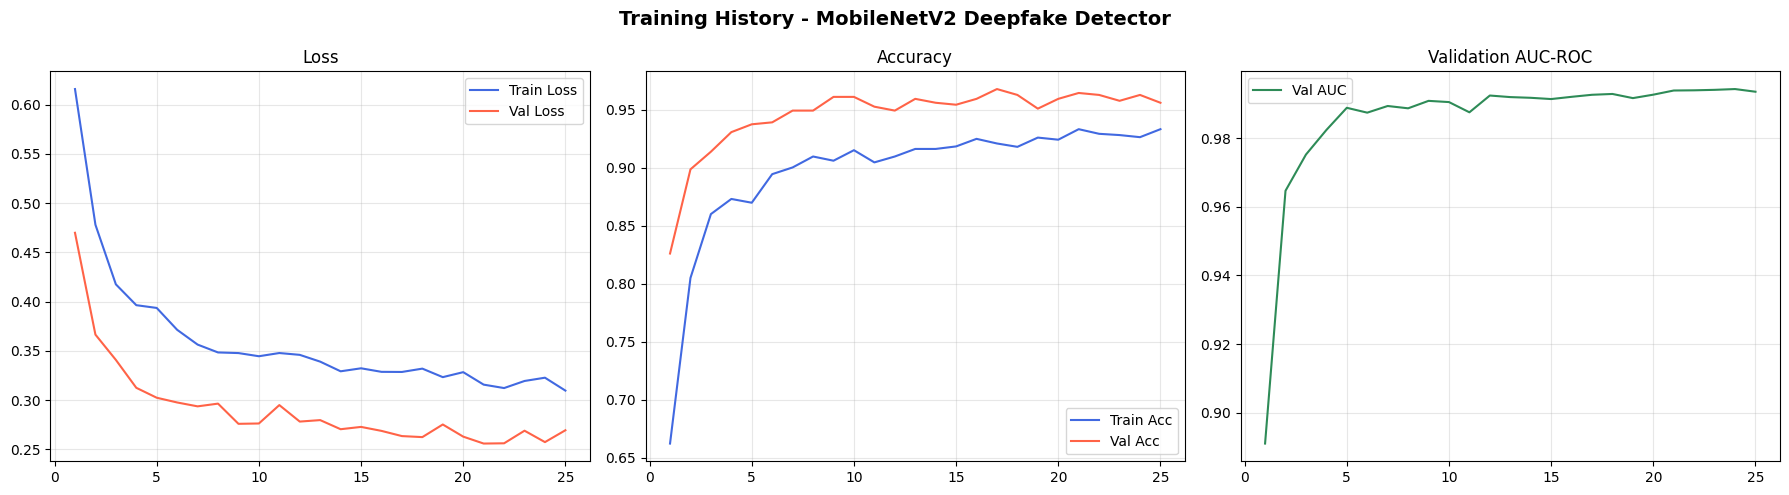

In [ ]:
# ===== PLOT TRAINING HISTORY =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History - MobileNetV2 Deepfake Detector', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train Acc', color='royalblue')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val Acc',   color='tomato')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, history['val_auc'], label='Val AUC', color='seagreen')
axes[2].set_title('Validation AUC-ROC'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# ===== LOAD BEST MODEL & TEST EVALUATION =====
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model dari epoch {checkpoint['epoch']+1}, Val AUC: {checkpoint['val_auc']:.4f}")

# Evaluasi pada test set
test_loss, test_acc, test_auc, test_probs, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

test_preds = (test_probs >= 0.5).astype(int)

print('\n' + '='*50)
print('HASIL EVALUASI TEST SET')
print('='*50)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test AUC-ROC  : {test_auc:.4f}')
print('\nClassification Report:')
print(classification_report(test_labels, test_preds,
                             target_names=['Real', 'Fake (GAN)']))

Loaded best model dari epoch 24, Val AUC: 0.9943

HASIL EVALUASI TEST SET
Test Loss     : 0.2715
Test Accuracy : 0.9542
Test AUC-ROC  : 0.9943

Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.94      0.95       292
  Fake (GAN)       0.94      0.97      0.96       298

    accuracy                           0.95       590
   macro avg       0.95      0.95      0.95       590
weighted avg       0.95      0.95      0.95       590



NameError: name 'test_labels' is not defined

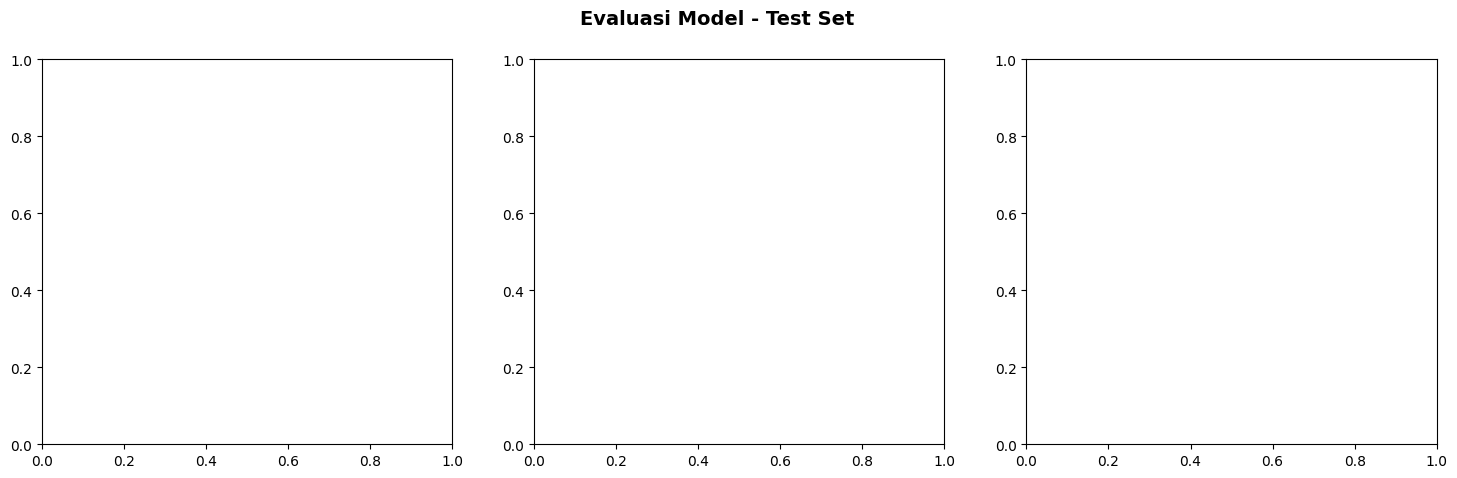

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, average_precision_score

# ===== CONFUSION MATRIX + ROC CURVE + PR CURVE =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evaluasi Model - Test Set', fontsize=14, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, color='royalblue', lw=2,
             label=f'ROC Curve (AUC = {test_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='royalblue')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(test_labels, test_probs)
ap = average_precision_score(test_labels, test_probs)
axes[2].plot(recall, precision, color='tomato', lw=2,
             label=f'PR Curve (AP = {ap:.4f})')
axes[2].fill_between(recall, precision, alpha=0.1, color='tomato')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'evaluation_metrics.png', dpi=150)
plt.show()